# Photon Calibration File

This is a demo that will take you through the process of using detanalysis' PhotonCalibration object to process calibration data produced with a laser. While the original class was written by the (now departed) Roger Romani in 2023, the class was reworked in 2026 by Will Matava to better mesh with TESSERACT's existing data structures (i.e. .hdf5 "filter files"). As a consequence, Will is probably the first person to ask for assistance with this demo, or the object in general. If he has graduated, tough luck. Better start reading code.

One more thing: this demo was written in Jan/Feb 2026 based on contemporary data on Tessy. If the data is still there, it's recommended that this notebook be run on Tessy, as it explicitly requires access to both the raw data as well as processed dIdV results. Minor tweaks to paths will still be necessary, but the code should otherwise run smoothly.


In [5]:
from detanalysis import PhotonCalibration, Analyzer, Semiautocut, MasterSemiautocuts
from detprocess import FilterBuilder

import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

proc_path = '/data/ucb/pylelab/run68/processed/continuous_I2_D20260119_T165249/feature_calib_I2_D20260120_T193442'
raw_path = '/data/ucb/pylelab/run68/raw/continuous_I2_D20260119_T165249'
# analyzer = Analyzer(proc_path)
# df = analyzer.df


### Checking on the data
When we run ls inside the dataset, we see many types of files:
- calib_bor: continuous data with DC offset and laser pulsing
- cont: continuous data with DC offset
- didV: didV with SQ wave offset
- iv_bor: IV; self explanatory

In [4]:
!ls /data/ucb/pylelab/run68/raw/continuous_I2_D20260119_T165249

calib_bor_I2_D20260119_T165303_F0001.hdf5
calib_bor_I2_D20260119_T165303_F0002.hdf5
calib_bor_I2_D20260119_T165303_F0003.hdf5
calib_bor_I2_D20260119_T165303_F0004.hdf5
calib_bor_I2_D20260119_T165303_F0005.hdf5
calib_bor_I2_D20260119_T165303_F0006.hdf5
calib_bor_I2_D20260119_T171743_F0001.hdf5
calib_bor_I2_D20260119_T171743_F0002.hdf5
calib_bor_I2_D20260119_T171743_F0003.hdf5
calib_bor_I2_D20260119_T171743_F0004.hdf5
calib_bor_I2_D20260119_T171743_F0005.hdf5
calib_bor_I2_D20260119_T171743_F0006.hdf5
calib_bor_I2_D20260119_T174223_F0001.hdf5
calib_bor_I2_D20260119_T174223_F0002.hdf5
calib_bor_I2_D20260119_T174223_F0003.hdf5
calib_bor_I2_D20260119_T174223_F0004.hdf5
calib_bor_I2_D20260119_T174223_F0005.hdf5
calib_bor_I2_D20260119_T174223_F0006.hdf5
cont_I2_D20260119_T170717_F0001.hdf5
cont_I2_D20260119_T170717_F0002.hdf5
cont_I2_D20260119_T170717_F0003.hdf5
cont_I2_D20260119_T170717_F0004.hdf5
cont_I2_D20260119_T170717_F0005.hdf5
cont_I2_D20260119_T170717_F0006.hdf5
cont_I2_D20260119_T173

### Generating a filter file from iv/didV Results
First thing's first: we need to run a didv processing. Doing so will later allow us to calculate the amount of energy that actually reaches our sensor's W TES. By comparing this number to the energy of the photons that we're sending into the fridge, we will be able to estimate the sensor's phonon collection efficiency.

Note that the number(s) we actually care about is(are) the sensor's "dPdI", or power-to-current transfer function. Everything else in the next few notebooks is merely a buildup to calculating this and storing it within the filterfile

In [7]:
didv_path = '/data/ucb/pylelab/run68/raw/continuous_I2_D20260119_T165249/didv_bor_I2_D20260119_T170334_F0001.hdf5'
continuous_path = '/data/ucb/pylelab/run68/raw/continuous_I2_D20260119_T165249/'
didv_series = 'I2_D20260119_T170334'
fb = FilterBuilder()

fb.didv.process_raw_data(channels = 'lbldmd1_1right',
      files_or_path = continuous_path,
      series = didv_series)

INFO: Getting raw data and processing channel lbldmd1_1right


In [8]:
iv_sweep_path = '/data/ucb/pylelab/run68/filterdata/iv_didv_I2_D20260117_T102801/ivsweep_analysis_D20260118_T104259.hdf5'
fb.didv.set_ivsweep_results_from_file(channels = 'lbldmd1_1right',
                     file_name = iv_sweep_path,
                     include_bias_parameters=True)
# Getting iv sweep results; we'll need these in order to extract physical parameters ("small-signal parameters") from dIdV
iv_sweep_results = fb.didv.get_ivsweep_results(channel = 'lbldmd1_1right')

INFO: Loading filter data from file /data/ucb/pylelab/run68/filterdata/iv_didv_I2_D20260117_T102801/ivsweep_analysis_D20260118_T104259.hdf5



lbldmd1_1right dIdV Fit Plots:


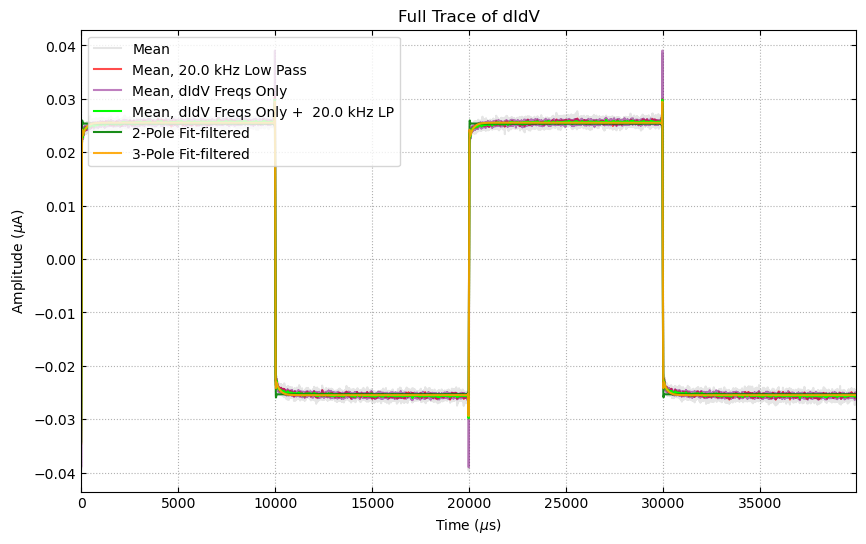

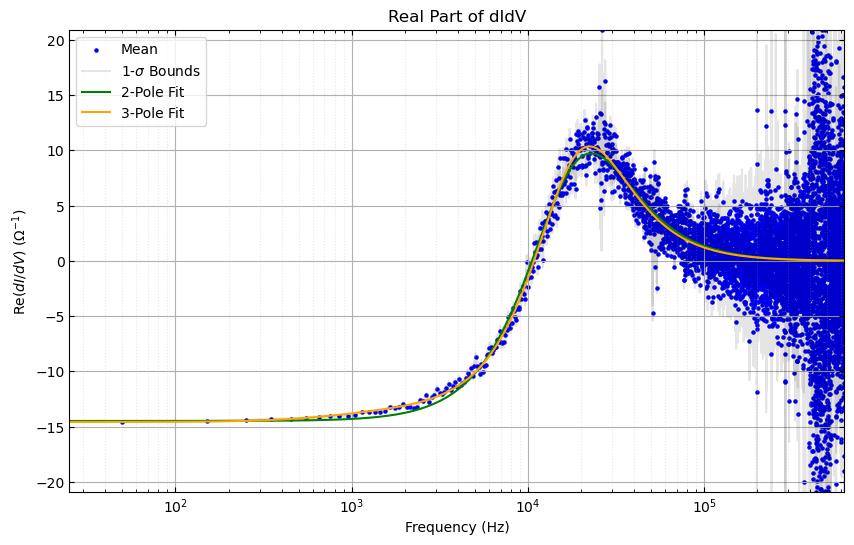

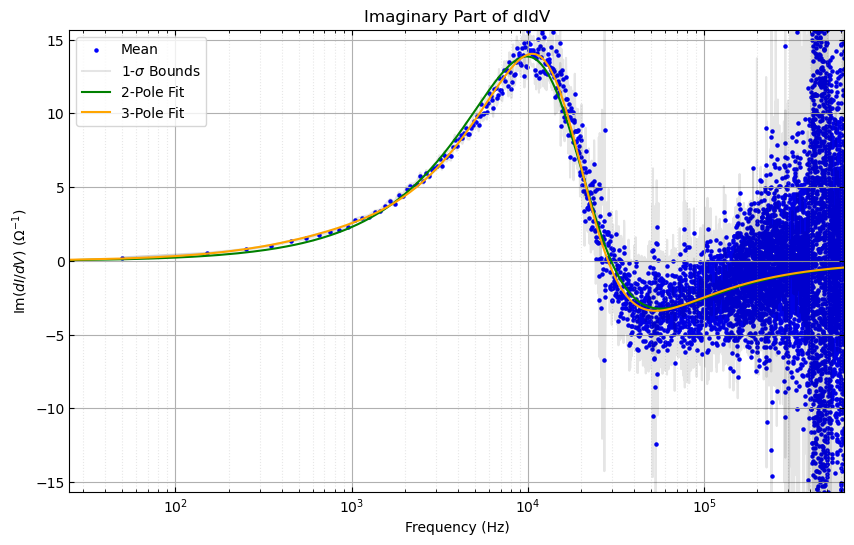

In [9]:
# fit iv and plot in both time and frequency space
fb.didv.dofit(list_of_poles = [2,3],
           channels = ['lbldmd1_1right'],
           )
fb.didv.plot_fit_result(channels = ['lbldmd1_1right'])



In [ ]:
# Exctract physical numbers (e.g. loop gain, beta, inductance, etc)
fb.didv.calc_smallsignal_params()

Calculating small signal parameters...
INFO: Calculating small signal parameters uncertainties for channel lbldmd1_1right
INFO: Using ibias=7.440e-06 A from IV sweep for channel lbldmd1_1right
INFO: Calculating small signal parameters for 2-poles model 
INFO: Calculating small signal parameters for 3-poles model 


In [11]:
#calculate dpdi for the relevant requencies. 
#Trace length_sec should be set to the length of the template that you eventually want to generate
fs = 1.25e6
trace_length_sec = .010
freqs = np.fft.fftfreq(int(trace_length_sec*fs), 1/fs)
fb.didv.calc_dpdi(freqs, channels = ['lbldmd1_1right'],
               list_of_poles = [2,3])

In [ ]:
# I have this commented out since the file is by default saved in this directory.
# Please don't save a bunch of garbage to my directory on Tessy
# fb.didv._save_path = '/home/wmatava/photon_calibration_Jan_2026/'
# fb.didv.save_hdf5(file_name = '/home/wmatava/photon_calibration_Jan_2026/test_didv_ff.hdf5',
#                overwrite = True)
# fb.didv.save_didv_data(file_path_name = '/home/wmatava/photon_calibration_Jan_2026/test_didv_ff.hdf5')

INFO: Saving filter/TES data to file /home/wmatava/photon_calibration_Jan_2026/test_didv_ff.hdf5! (overwrite=True)
INFO: Saving filter/TES data to file /home/wmatava/photon_calibration_Jan_2026/test_didv_ff.hdf5! (overwrite=True)


### Confirm that our filter file was saved correctly
Optional, but we're going to break into the filter file that we just generated in order to see what was saved

In [13]:
import pytesdaq.io as h5io

filter_io = h5io.FilterH5IO('/home/wmatava/photon_calibration_Jan_2026/test_didv_ff.hdf5')
didv_dataframe = filter_io.load()

In [15]:
#Lot's of stuff got saved!
#The important objects for us are dpdi_3poles_default and dpdi_err_3poles_default
#(You could also use the 2pole results if you so desired)
for key in didv_dataframe['lbldmd1_1right'].keys():
    print(key)

didv_results_2poles_biasparams_default
didv_results_2poles_biasparams_default_metadata
didv_results_2poles_errors_default
didv_results_2poles_errors_default_metadata
didv_results_2poles_fit_default
didv_results_2poles_fit_default_metadata
didv_results_2poles_params_default
didv_results_2poles_params_default_metadata
didv_results_2poles_smallsignalparams_default
didv_results_2poles_smallsignalparams_default_metadata
didv_results_2poles_ssp_light_default
didv_results_2poles_ssp_light_default_metadata
didv_results_3poles_biasparams_default
didv_results_3poles_biasparams_default_metadata
didv_results_3poles_errors_default
didv_results_3poles_errors_default_metadata
didv_results_3poles_fit_default
didv_results_3poles_fit_default_metadata
didv_results_3poles_params_default
didv_results_3poles_params_default_metadata
didv_results_3poles_smallsignalparams_default
didv_results_3poles_smallsignalparams_default_metadata
didv_results_3poles_ssp_light_default
didv_results_3poles_ssp_light_default_m

### Photon Calibration Pre-Processing

Okay, we've done the dirty work of understanding the electrothermal characteristics of our sensors, so we can start looking at phonon pulses generated with a laser. The workflow here is going to be:
1. Load in the (pre-)processed data. This has been processed using the process.py script from detprocess using a dummy template
2. Introduce some quality cuts in order to clean up the data. This isn't strictly necessary in a day-to-day setting, but we'll do so to illustrate how.
3. Fit the observed spectrum of OF amps post-cuts to a series of gaussians


In [7]:
# Load in processed data. This is the same Analyzer object you used if you ever did continuous analysis
analyzer = Analyzer(proc_path)

In [8]:
# Applying some simple basline cuts using semiautocuts
# the more careful user might throw in a cut based on chi2 too
cut_pars_baseline = {'sigma_upper':2.0}


baseline_cut = Semiautocut(analyzer.df, cut_rq = 'baseline_pre', channel_name='lbldmd1_1right',
                               cut_pars=cut_pars_baseline)

bcut_mask = baseline_cut.do_cut(lgcdiagnostics=False)


analyzer.df['slope_lbldmd1_1right'] = analyzer.df['baseline_pre_lbldmd1_1right'] - analyzer.df['baseline_end_lbldmd1_1right']

cut_pars_slope = {'sigma':2.0}

slope_cut = Semiautocut(analyzer.df, cut_rq = 'slope', channel_name='lbldmd1_1right',
                               cut_pars=cut_pars_slope)

cuts_list = ['cut_baseline_pre_lbldmd1_1right',
             'cut_slope_lbldmd1_1right']

MSAC = MasterSemiautocuts(analyzer.df, cuts_list, 'lbldmd1_1right',)
MSAC.combine_cuts(cut_name = 'cut_all')

In [10]:
# Initializing the photoncalibration object.
PC = PhotonCalibration(template_model = 'threepole', # model we'll fit power-space pulses to; twopole/fourpole alternatives
                       photon_energy_ev = 3.04, # photon energy in eV
                       analyzer_object = analyzer, # processed dat object
                       filterfile_path = '/home/wmatava/photon_calibration_Jan_2026/test_didv_ff.hdf5', # path to filterfile containing dpdi
                       npoles = 3, #which dpdi result to pull from filterfile                       
                       dpdi_tag = 'default', #which dpdi result to pull from filterfile
                       channel_name = 'lbldmd1_1right', #Channel of interest
                       trace_length_sec=10e-3, 
                       pretrigger_window_sec=5e-3,
                       )

Here we're going to fit the a histogram of amplitudes. There are three knobs to turn:
1. The number of peaks (gaussians) to model
2. Whether the peak areas ought to be poisson-distribued (default no; not suggested)
3. Whether the peaks ought to be evenly spaced (default yes, but non-linearities can occur)

It's crucial that you prescribe a reasonable guess for the relevant parameters using the guess argument to the fit_spectrum method. However, the length and formatting of this guess is by nature a function of how you choose to turn these knobs. This makes formatting a bit arbitrary, but we'll prescribe below:

non-poisson distribued/equal spacing:
- guess ~ [peak_1_mean, peak_0_width, peak_1_width, ..., peak_0_height, peak_1_height, ...]

poisson distributed/equal spacing
- guess ~ [peak_1_mean, peak_0_width, peak_1_width, ..., mean_no_photons, peak_0_height]

non-poisson distribued/unequal spacing:
- guess ~ [peak_0_mean, peak_1_mean, ..., peak_0_width, peak_1_width, ..., peak_0_height, peak_1_height, ...]

poisson distribued/unequal spacing:
- guess ~ [peak_0_mean, peak_1_mean, ..., peak_0_width, peak_1_width, ..., mean_no_photons, peak_0_height]

An ellipses here indicates that this should repeated for however many peaks you choose to fit


Event amps: [3.86683078e-08 1.90415097e-08 6.03841624e-08 ... 3.80542841e-08
 1.16211455e-07 9.27769560e-08]
Number of events: 165072
 
Guess: [2e-08, 1.5e-09, 3e-09, 4e-09, 6e-09, 8e-09, 4000, 5000, 5000, 4000, 2000]


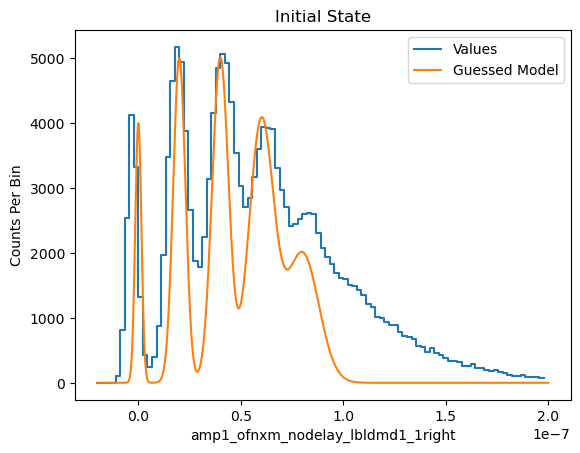

Guess: [2e-08, 1.5e-09, 3e-09, 4e-09, 6e-09, 8e-09, 4000, 5000, 5000, 4000, 2000]
Bounds lower: [1e-08, 7.5e-10, 1.5e-09, 2e-09, 3e-09, 4e-09, 1000.0, 1250.0, 1250.0, 1000.0, 500.0]
Bounds upper: [3.0000000000000004e-08, 2.25e-09, 4.5e-09, 6.000000000000001e-09, 9e-09, 1.2000000000000002e-08, 8000.0, 10000.0, 10000.0, 8000.0, 4000.0]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.8306e+04                                    3.02e+04    
       1              2         1.8995e+04      9.31e+03       2.19e+03       4.58e+04    
       2              3         1.3982e+04      5.01e+03       1.59e+03       3.40e+04    
       3              4         1.3812e+04      1.71e+02       3.09e+02       2.33e+04    
       4             25         1.3812e+04      0.00e+00       0.00e+00       2.33e+04    
`xtol` termination condition is satisfied.
Function evaluations 25, initial cost 2.8306e+04, final cost 1.3812e+04, fi

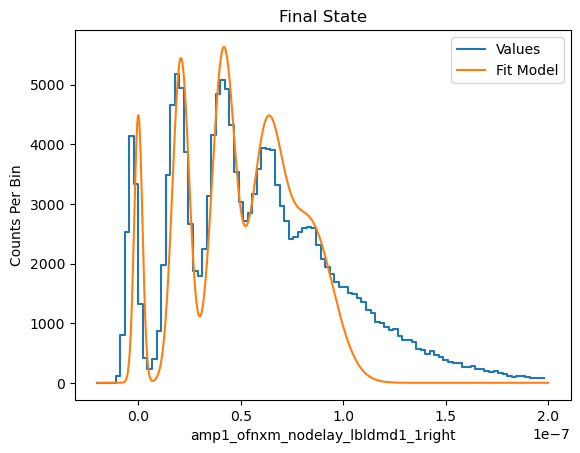

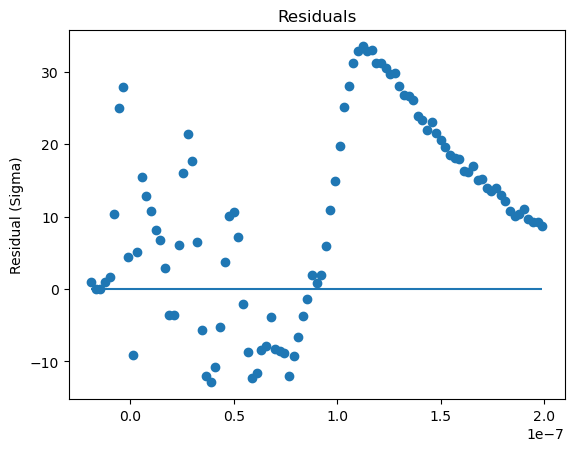

 
-----------
Fit Results: 
Peak spacing: 2.0776823386512487e-08 +/- 1.9584152957044344e-11
Peak 0 width: 2.0071815797297304e-09 +/- 9.105330590638901e-11
Peak 0 height: 4487.864634023129 +/-223.1264963172486
Peak 1 width: 4.122511758816514e-09 +/- 4.856353134187102e-11
Peak 1 height: 5441.026929456473 +/-67.16423185370301
Peak 2 width: 5.616372290473509e-09 +/- 5.5250755446843076e-11
Peak 2 height: 5523.545105251283 +/-57.602639946571195
Peak 3 width: 7.711313618427415e-09 +/- 8.334102791396667e-11
Peak 3 height: 3869.75136513493 +/-42.1507996095495
Peak 4 width: 1.1640961431281548e-08 +/- 1.3260835429113626e-10
Peak 4 height: 2694.960847995967 +/-30.15204572046637


In [11]:
# Fitting the spectrum
# Clearly the fit is imperfect; you can probably get a better fit by relaxing the equal spacing constrain, but 
# I figure that that's more your problem than mine at this point.

guess = [2e-8, #single-photon amplitude 
         1.5e-9, 3e-9, 4e-9, 6e-9, 8e-9, #peak widths
         4000, 5000, 5000, 4000, 2000, #peak heights
         ]

_ = PC.fit_spectrum('amp1_ofnxm_nodelay_lbldmd1_1right', #the name of the OF amplitude RQ we'll be fitting
                    'cut_all', #the cut to apply that we created 2 cells above
                    lgc_plot=True, lgc_diagnostics=True, #these can be turned off as desired
                    poisson = False, # Whether the peak areas should obey poisson stats
                    eqspacing = True, # Whether we should allow for unequal spacing between neighboring peaks (i.e. TES nonlinearity)
                    npeaks = 5, # number of gaussians to fit
                    lgc_ylog=False, #of the diagnostic plots
                    guess = guess, # Guess for 
                    bounds=None, #automatically created if None
                    bins = np.linspace(-2e-8, 2e-7, 100), #used for the fitting and plots
                    )



### Sampling the distribution and fitting pulse shapes

Here's where the code is actually doing what we want: ascertaining photon templates and estimating resolution. We'll follow these steps:
1. Based on the above fit, we'll define cuts that pass only photons in the nth observed peak
2. Pull waveforms that pass these cuts and calculate their average pulse shape
3. Using dPdI, convert this average pulse shape into power space and fit to our prescribed template

Peak center: 2.0776823386512487e-08
Width to cut: 3.091883819112386e-09
 
Modified cut name: 
 


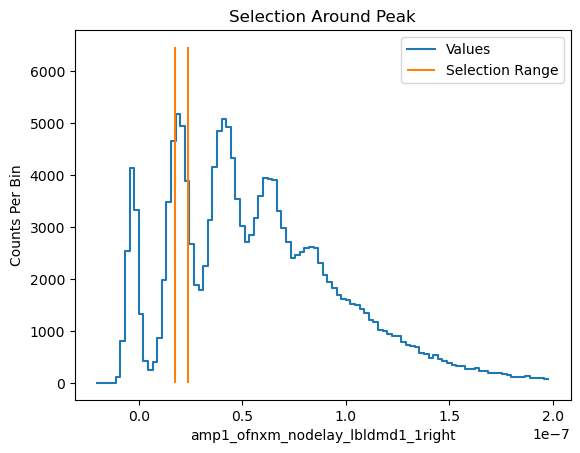

include_previous_cuts: False
 
 
include_previous_cuts: False
Using default cut parameters
Selection list: ['_lims_mask']
Cut parameters: {'val_lower': 1.76849395674001e-08, 'val_upper': 2.3868707205624874e-08}
Number of events passing selection: 179290
Lower limit for cuts: 1.76849395674001e-08
Upper limit for cuts: 2.3868707205624874e-08


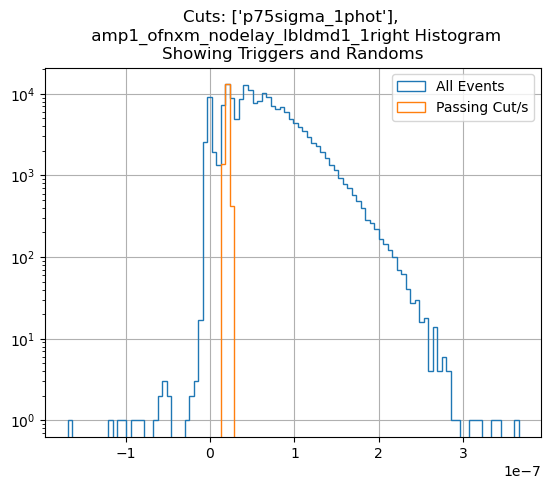

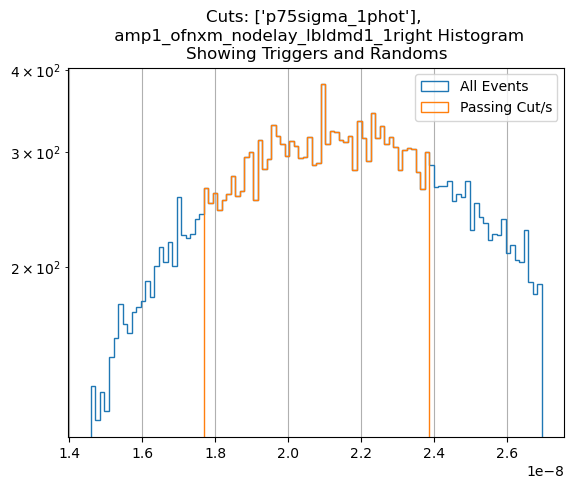

In [12]:
# defined a photon cut around the first peak. This is biased commensurate to 
# our fit's mdeicority, but is sufficient for our pedagogy
PC.define_photon_cut(1, #photon peak number
                     0.75, #width to accept (in sigma)
                    'p75sigma_1phot', #the cut name, best to standardize as this or similar
                    lgc_diagnostics=True)


Photon cut name: p75sigma_1phot
INFO: Number of events found = 3000


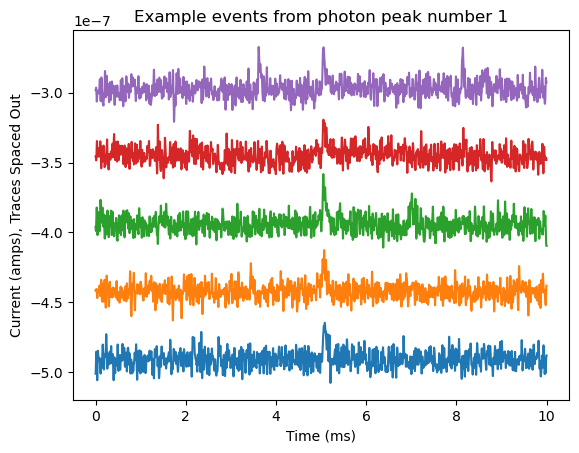

In [ ]:
#Load events from raw and plot a few as a sanity check
PC.load_events(1, #photon peak to load in case we defined cuts for multiple different peaks
               number_events_limit=3000,
               pretrigger_window=5e-3, trace_length=10e-3, 
               raw_path='/data/ucb/pylelab/run68/raw/continuous_I2_D20260119_T165249/', 
               lgc_plot_example_events=True, example_events_num=5)


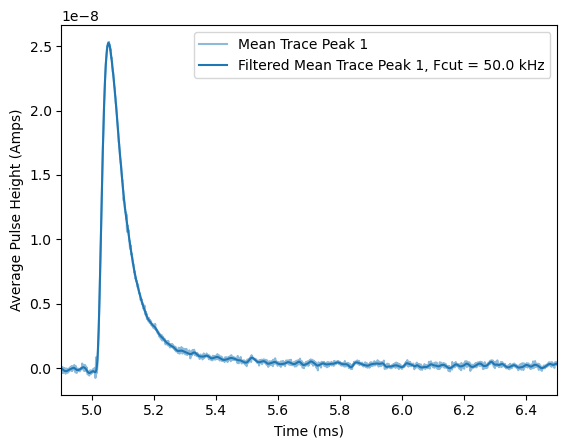

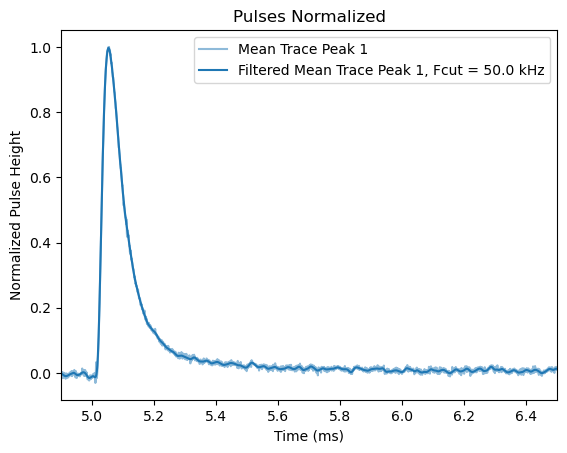

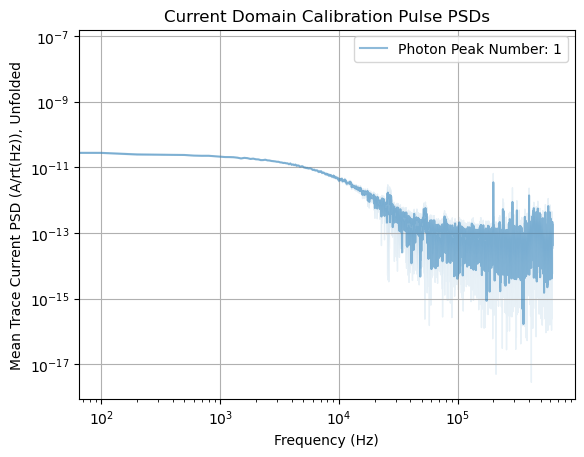

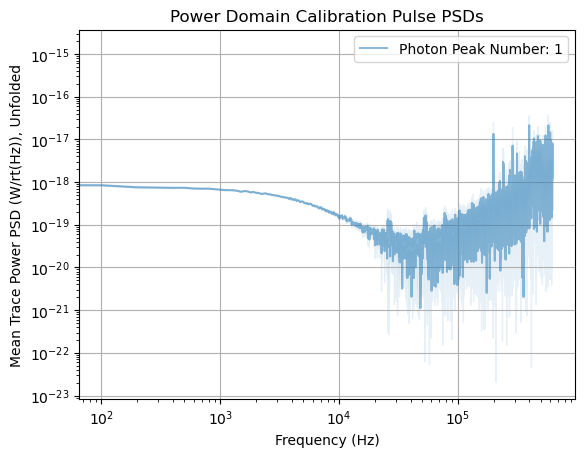

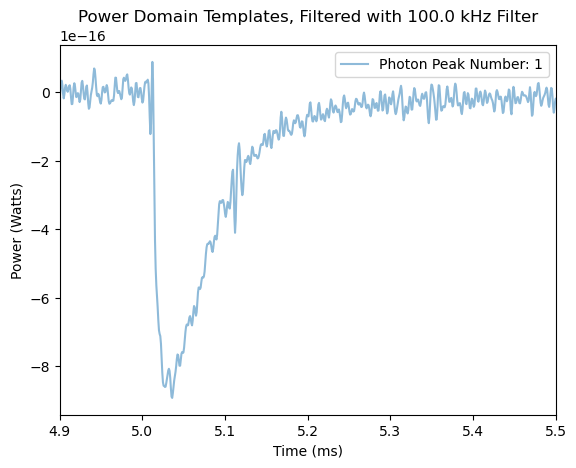

In [14]:
# Calculate average pulse in both frequency-space and time space 
# (The latter is just a scaled fft of the former)
PC.calculate_average_pulses(lgc_plot_average_trace=True,
                            time_lims = [4.9e-3, 6.5e-3])
PC.calculate_frequency_domain_templates(lgc_plot=True, filter_freq= 100e3)

Guess: [1.4e-15, 0, 6e-05, 0.0001, 1e-05]
Bounds is None


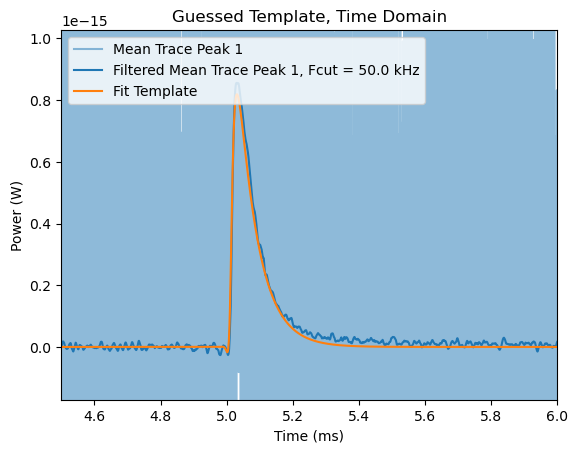

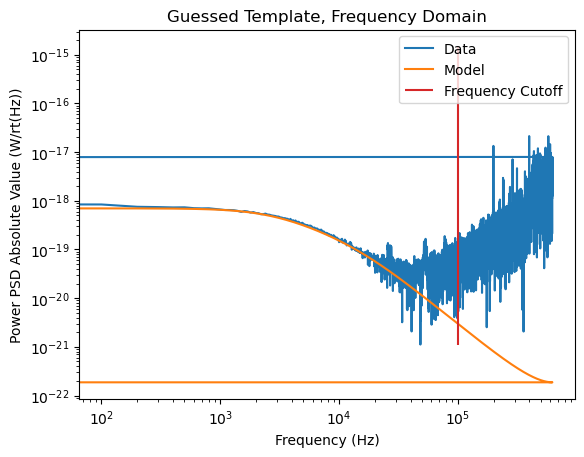

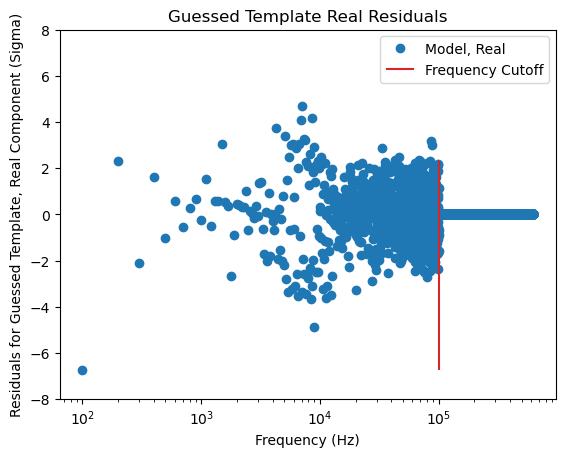

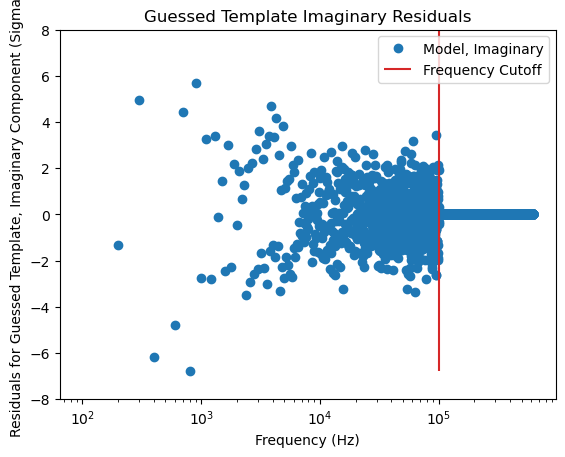

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.2904e+03                                    1.69e+19    
       1              4         2.5406e+03      7.50e+02       7.32e-06       3.87e+18    
       2              6         2.4452e+03      9.54e+01       3.66e-06       1.33e+18    
       3              7         2.4188e+03      2.64e+01       7.32e-06       4.24e+18    
       4              9         2.3569e+03      6.19e+01       1.83e-06       1.31e+18    
       5             10         2.3500e+03      6.85e+00       3.66e-06       2.20e+18    
       6             11         2.3327e+03      1.73e+01       3.66e-06       4.36e+17    
       7             12         2.3235e+03      9.19e+00       7.32e-06       9.62e+17    
       8             13         2.3207e+03      2.85e+00       1.46e-05       3.35e+18    
       9             14         2.3003e+03      2.04e+01       3.66e-06       4.06e+16    

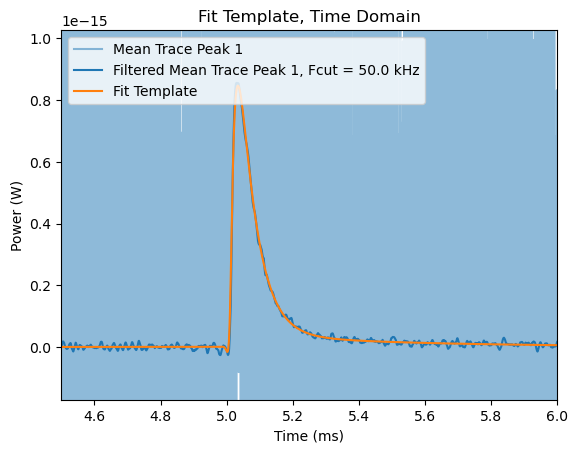

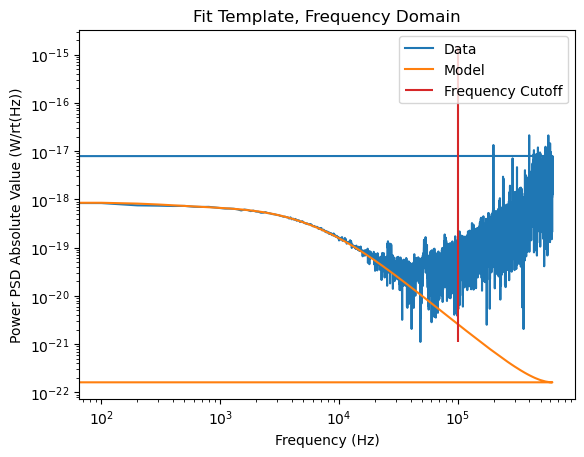

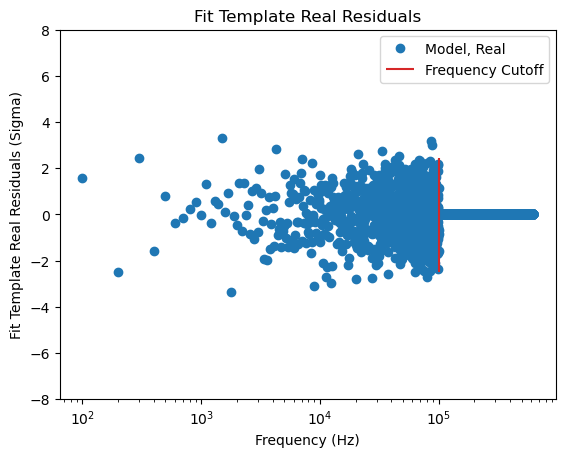

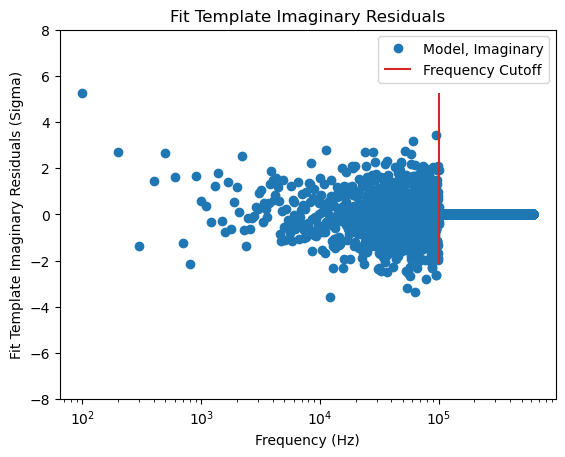

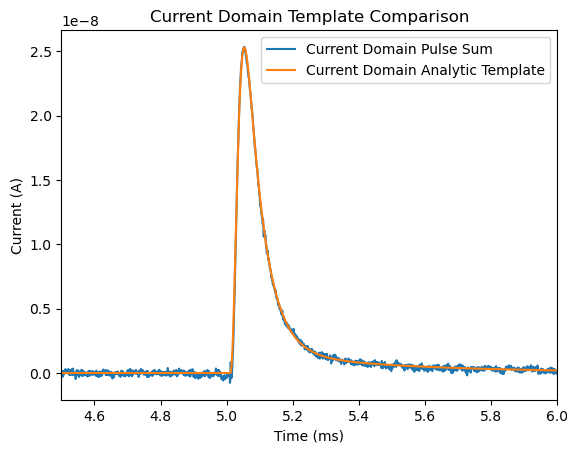

popt: 
[1.76474513e-15 4.41189721e-17 5.07781182e-05 4.81388661e-04
 1.32906269e-05]
 
cov:
[[ 4.46033951e-34  3.13342619e-35 -9.85881375e-24 -2.65210418e-22
   3.03368015e-24]
 [ 3.13342619e-35  9.69326818e-36 -1.20836684e-24 -9.96019447e-23
   2.14480908e-25]
 [-9.85881375e-24 -1.20836684e-24  2.63580550e-13  1.11906952e-11
  -6.48322146e-14]
 [-2.65210418e-22 -9.96019447e-23  1.11906952e-11  1.35275282e-09
  -1.92114426e-12]
 [ 3.03368015e-24  2.14480908e-25 -6.48322146e-14 -1.92114426e-12
   2.28095564e-14]]
 
Amplitude 1: 1.7647451294566415e-15 +/- 2.1119515873528656e-17
Amplitude 2: 4.411897209594044e-17 +/- 3.1134013837920384e-18
Fall Time 1: 50.77811823851817 +/- 0.5134009643839168 us
Fall Time 2: 481.3886609531307 +/- 36.77978826019123 us
Rise Time: 13.290626851707835 +/- 0.15102832966209154 us


In [ ]:
# Fitting the template. We' tweak dt a bit by hand to account for some small misalignment in the pulse timing
PC.dt = 1e-5
PC.fit_templates(1, #photon peak number to fit
                 
                      guess = [1.4e-15, 0, 6e-5, 1e-4, 1e-5], 
                      f_fit_cutoff=100e3, #above a certain frequency, basically all the template informatio
                                          #is just noise. This cutoff prevents the noise from being fit by
                                          #setting the weights to zero. This is similar to a low frequency
                                          #chi2, conceptually
                      filter_freq=50e3, #The low pass filter frequency for plotting
                      time_lims=[4.5e-3, 6e-3] #time limits for the diagnostic plots
                      )


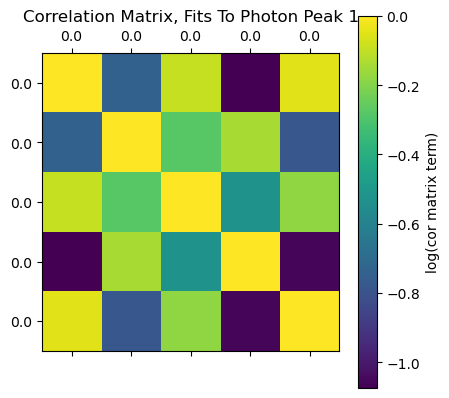

In [ ]:
# Plot the correlation matrix for the fit paremeters
PC.get_correlation_matrix_visualization(photon_peak_number=1)

### The fruits of our labor
All of the work is done! Now it's time to pull the relevant information:
- Energy resolution (phonon-mediated); determined solely from the (admittedly poor) fit to the amplitude spectrum
- Phonon collection efficiency; determined using the dpdi fit that we did before touching the calibration data
- The current-space template, which you can save to a filter file and use to process continuous data to your little heart's content



In [32]:
_ = PC.get_spectrum_energy_res()
print('\n')
_ = PC.get_template_phonon_collection_effiency(photon_peak_number = 1)

5 fit
Inter-peak spacing is assumed to be uniform
Measuring energy resolution using single-photon energy
and peak width relative to peak spacing in OFAmp
 
Energy resolution: 0.6031930634274814 +/- 0.007105664447969734 eV


Energy in template: 8.680180331331808e-20 +/- 8.80173959545768e-22 J
Energy in template: 0.5418168562817315 +/- 0.0054940458554846834 eV
Photon Energy in Peak: 4.87008e-19 J
Phonon Collection Efficiency: 0.17823486126165908 +/- 0.00180730903711185


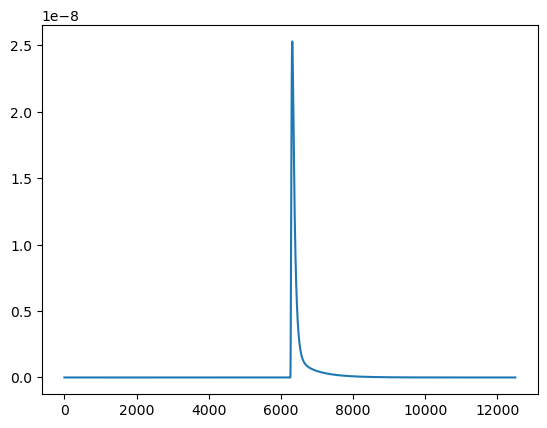

In [35]:
template = PC.get_current_template(photon_peak_number=1,
                                   lgc_plot=False)

fig, ax = plt.subplots()
ax.plot(template)